# Exploratory Data Analysis

In [1]:
import pickle
import os
import nibabel as nib
import numpy as np
import math
import torchio as tio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patch

/home/qj474765/master_thesis/MedSliM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_nifti_image(data_root_dir, exam_id, view_plane):
    nifti_file_path = f'{data_root_dir}/{view_plane}/{exam_id}.nii.gz'
    return nib.load(nifti_file_path).get_fdata()

In [3]:
VIEW_PLANES = ['sagittal', 'coronal', 'axial']

## MRNet

### Before `torchio.transforms`

In [ ]:
# Load an image
data_root_dir = '/hpcwork/rwth1833/datasets/preprocessed/MRNet/train'
exam_id = '1129'
image = load_nifti_image(data_root_dir, exam_id, VIEW_PLANES[0])
image.shape

(256, 256, 34)

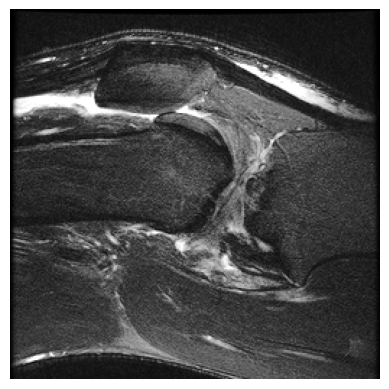

In [9]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

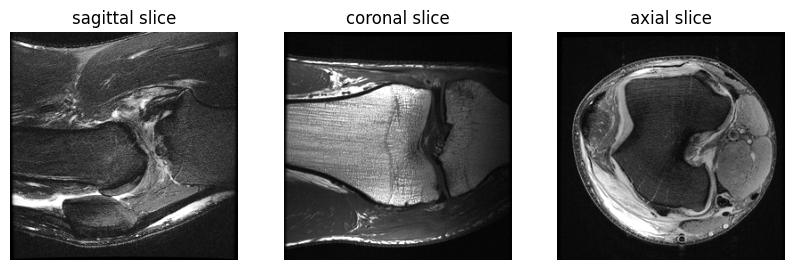

In [ ]:
# Access center slices along different axes (e.g., axial, sagittal, coronal)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i, slice_view in enumerate(VIEW_PLANES):
    image = load_nifti_image(data_root_dir, exam_id, slice_view)
    slice_idx = image.shape[-1] // 2
    axes[i].imshow(image[:, :, slice_idx], cmap='gray', origin='lower')
    axes[i].set_title(f'{slice_view} slice')
    axes[i].axis('off')
plt.show()

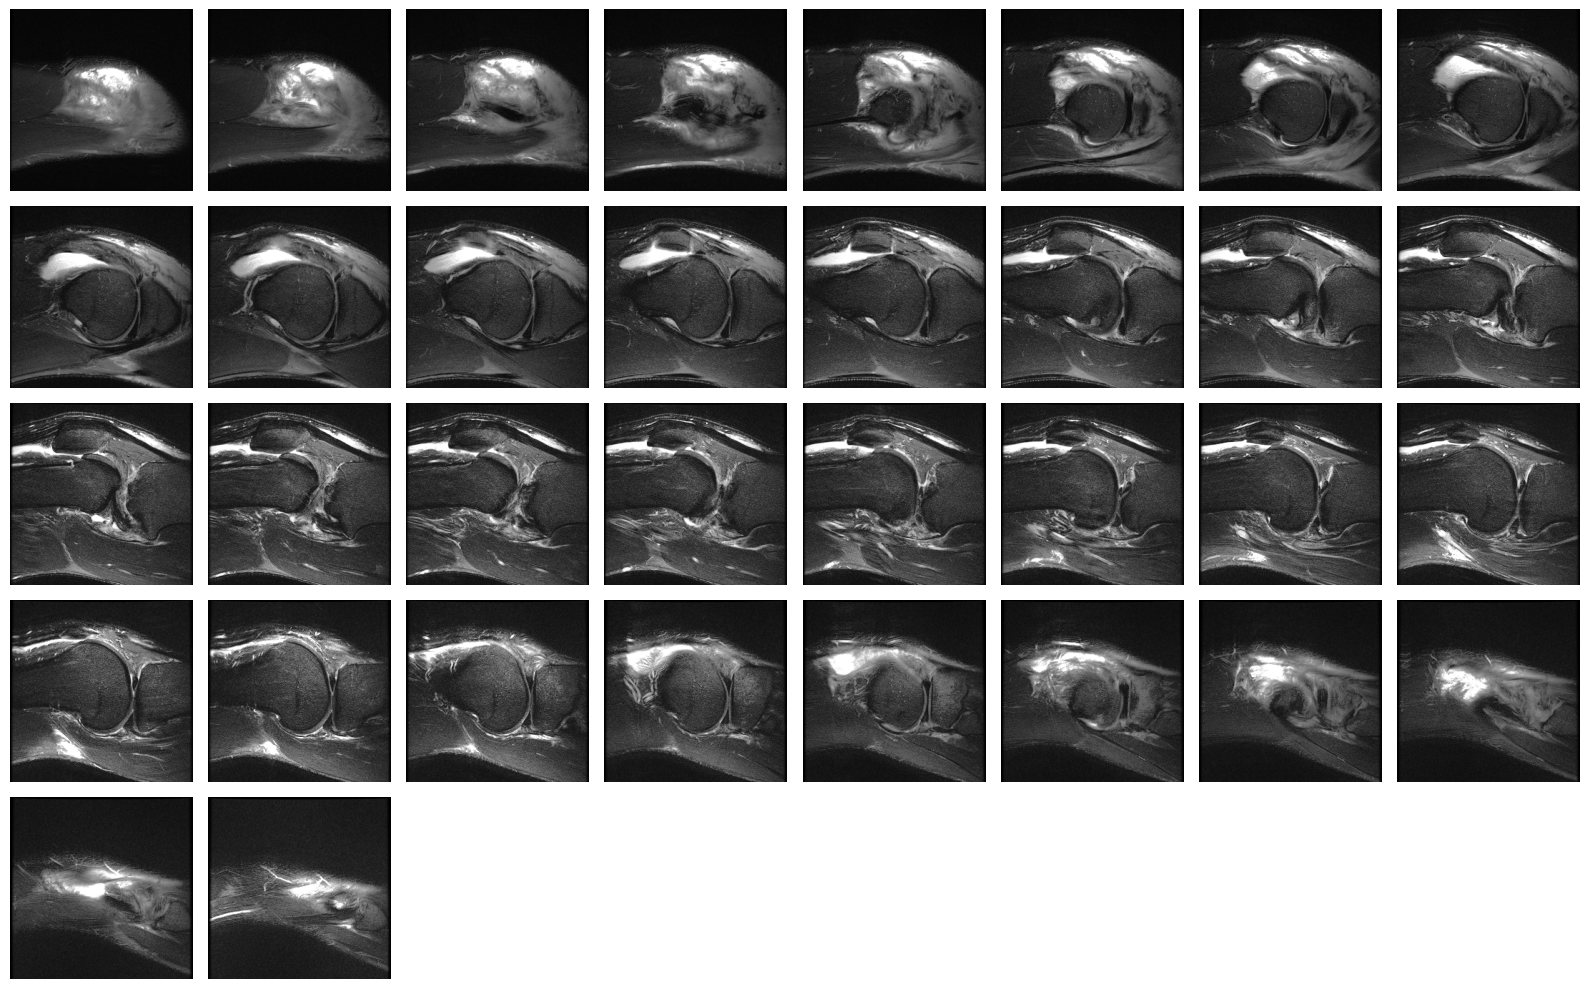

In [4]:
num_slices = image.shape[-1]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(image[:, :,i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

### After `torchio.transforms`

In [5]:
from med_slim.utils.preprocessing.transforms import get_transforms
_, val_tf = get_transforms(model_name="dinov2", num_slices=32, to_tensor=True)

In [6]:
original_image = tio.ScalarImage(nifti_file_path)
print(f"Original image shape: {original_image.shape}")
print(f"Original image spacing: {original_image.spacing}")

Original image shape: (1, 256, 256, 34)
Original image spacing: (1.0, 1.0, 1.0)


In [7]:
transformed_image = val_tf(original_image)
print(f"Transformed image shape: {transformed_image.shape}")

Transformed image shape: torch.Size([1, 32, 224, 224])


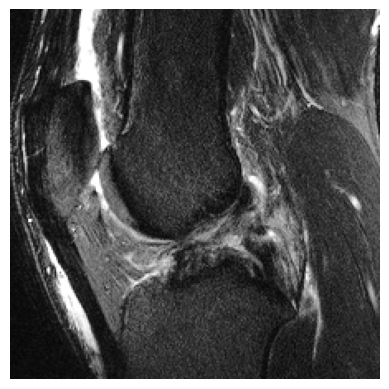

In [8]:
transformed_image = transformed_image.numpy().squeeze(axis=0) # Remove channel dimension for visualization 
plt.imshow(transformed_image[slice_idx], cmap='gray')
plt.axis('off')
plt.show()

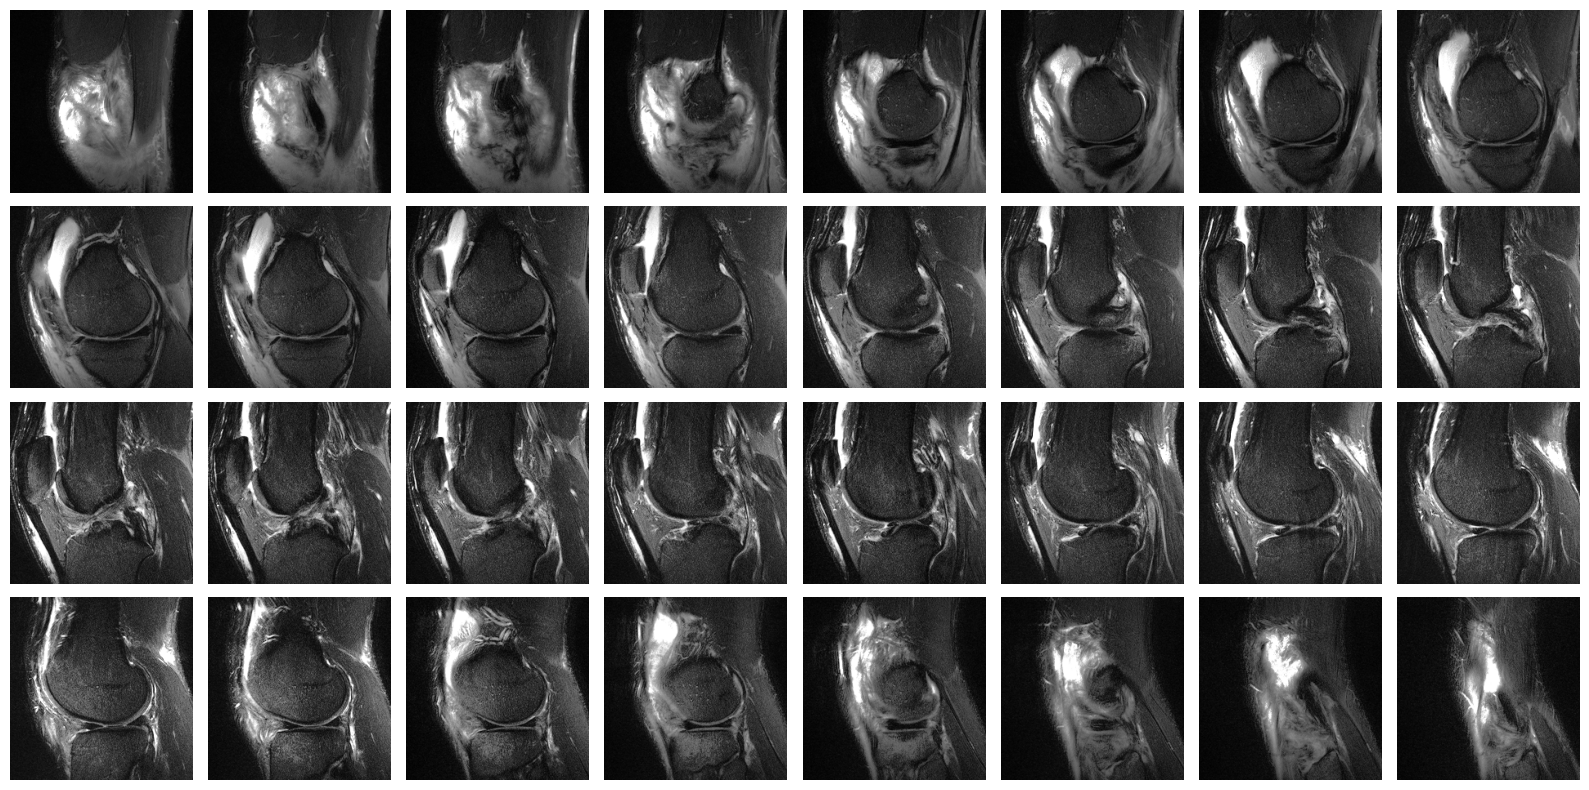

In [9]:
num_slices = transformed_image.shape[0]
n_cols = 8
n_rows = math.ceil(num_slices / n_cols)

plt.figure(figsize=(n_cols * 2, n_rows * 2))
for i in range(num_slices):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(transformed_image[i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## kneeMRI

In [13]:
# directory where the volumetric data is located
volumetric_data_dir = '/hpcwork/rwth1833/datasets/kneeMRI/vol_train'

# path to metadata csv file
metadata_csv_path = '/hpcwork/rwth1833/datasets/kneeMRI/metadata.csv'

# names=True loads the interprets the first row of csv file as column names
# 'i4' = 4 byte signed integer, 'U20' = unicode max 20 char string
metadata = np.genfromtxt(metadata_csv_path, delimiter=',', names=True, 
    dtype='i4,i4,i4,i4,i4,i4,i4,i4,i4,i4,U20') 

print('Column names:')
print(metadata.dtype.names)

# Select all rows where examID == 502889
exams = metadata[metadata['examId'] == 502889]


Column names:
('examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename')



Shape of volume "/hpcwork/rwth1833/datasets/kneeMRI/vol_train/502889-5.pck": (30, 320, 320)


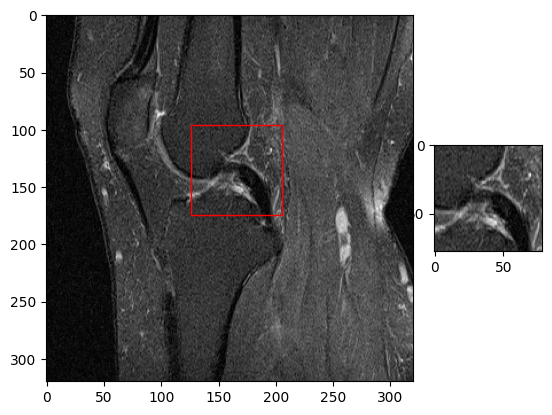

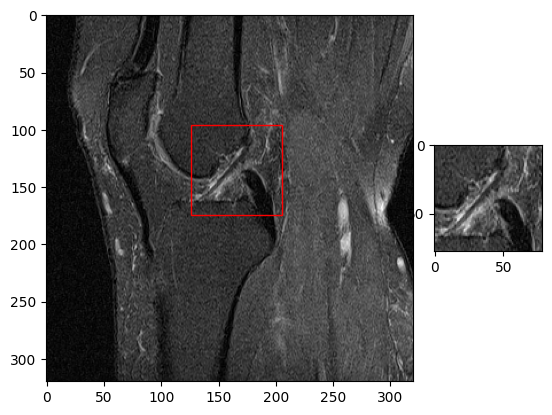

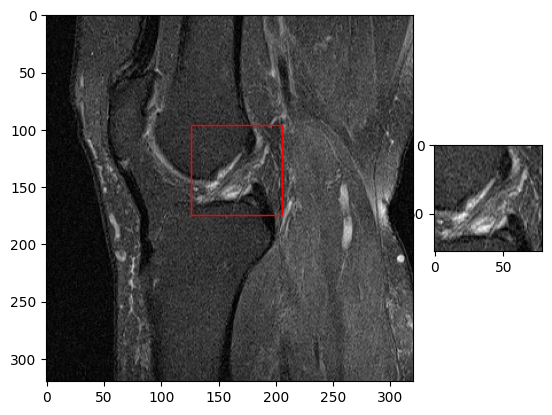

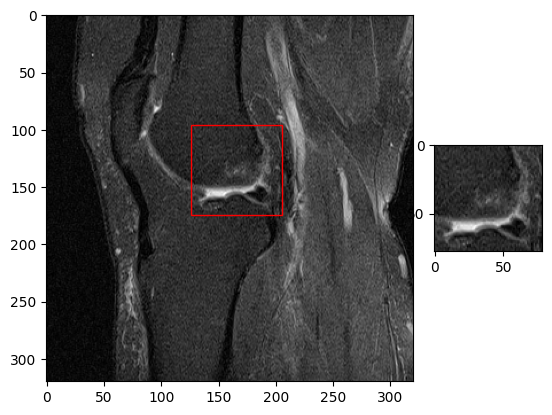


Shape of volume "/hpcwork/rwth1833/datasets/kneeMRI/vol_train/502889-8.pck": (30, 320, 320)


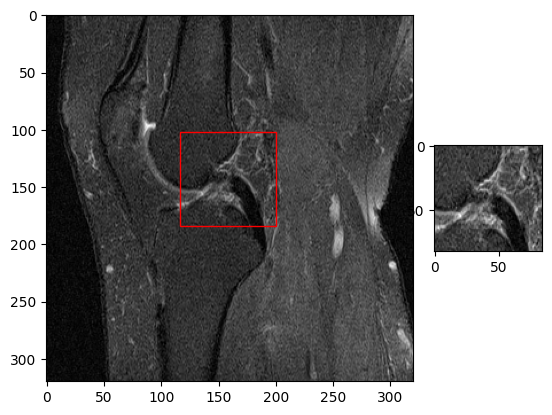

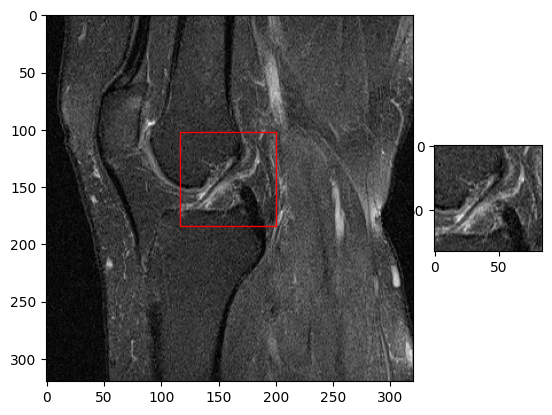

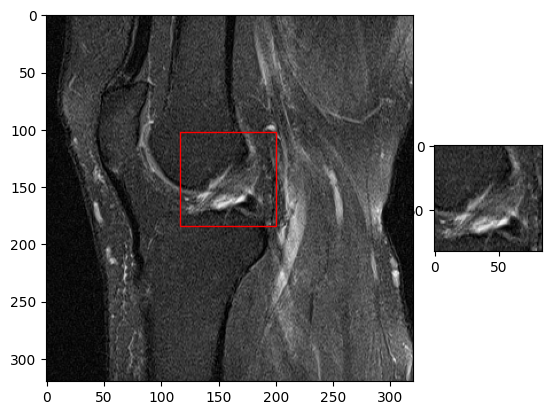

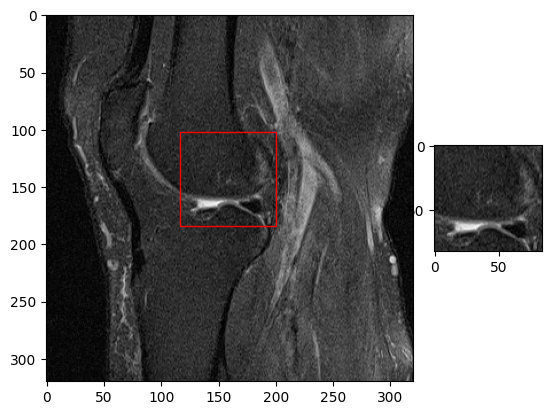

In [14]:
for exam in exams:
    vol_data_file = exam['volumeFilename']

    vol_data_path = os.path.join(volumetric_data_dir, vol_data_file)

    # Load data from file
    with open(vol_data_path, 'rb') as file_handler: # Must use 'rb' as the data is binary
        volumetric_data = pickle.load(file_handler)
    
    print('\nShape of volume "%s":' % vol_data_path, volumetric_data.shape)
    
    # Get all roi slices from volume
    z_start = exam['roiZ']
    depth = exam['roiDepth']
    
    for z in range(z_start, z_start + depth):
    
        slice = volumetric_data[z, :, :]
        
        # Get roi dimensions
        x, y, w, h = [exam[attr] for attr in ['roiX', 'roiY', 'roiWidth', 'roiHeight']]
        
        # Extract ROI
        roi = slice[y:y+h, x:x+w]
        
        # Plot slice and roi
        figure = plt.figure()
        plot = plt.subplot2grid((1, 4), (0, 0), 1, 3) # This makes the slice plot larger than roi plot
        plot.add_patch(patch.Rectangle((x, y), w, h, fill=None, color='red'))
        plot.imshow(slice, cmap='gray')
        plot = plt.subplot2grid((1, 4), (0, 3), 1, 1)
        plot.imshow(roi, cmap='gray')
        
        plt.show()

In [ ]:
data_root_dir = '/home/rwth1833/datasets/preprocessed/kneeMRI/train'
image = load_nifti_image(data_root_dir,"776202-5", VIEW_PLANES[0])
image.shape

(320, 320, 30)

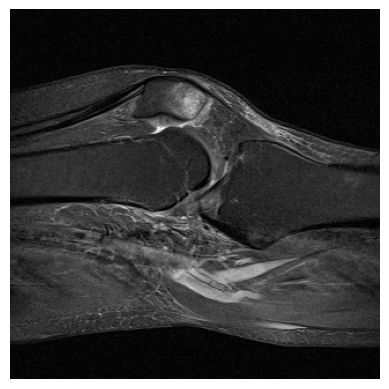

In [7]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

## fastMRI

In [5]:
data_root_dir = f'/work/rwth1833/datasets/preprocessed/fastMRI/train'
view_plane = VIEW_PLANES[0]
exam_id = 'study_42f9ce23_MR7_0d20a763'
image = load_nifti_image(data_root_dir,exam_id, view_plane)
image.shape

(512, 512, 30)

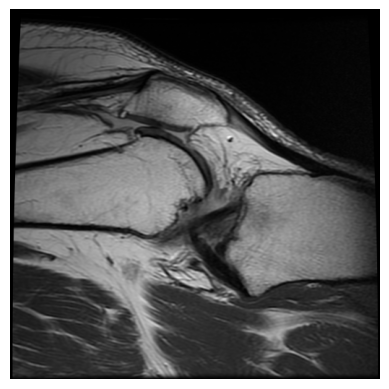

In [6]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

In [7]:
data_root_dir = f'/work/rwth1833/datasets/preprocessed/fastMRI/train/'
view_plane = VIEW_PLANES[2]
exam_id = 'study_39a470be_MR4_21d1f671'
image = load_nifti_image(data_root_dir,exam_id, view_plane)
image.shape

(512, 512, 38)

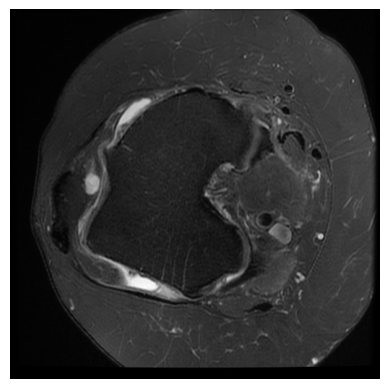

In [8]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()

In [9]:
data_root_dir = f'/work/rwth1833/datasets/preprocessed/fastMRI/train/'
view_plane = VIEW_PLANES[1]
exam_id = 'study_16dabf31_MR10_93ddb94c'
image = load_nifti_image(data_root_dir,exam_id, view_plane)
image.shape

(512, 512, 28)

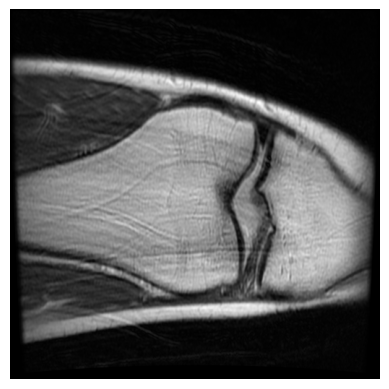

In [10]:
slice_idx = image.shape[-1] // 2
plt.imshow(image[:, :, slice_idx], cmap='gray')
plt.axis('off')
plt.show()